# M504 AI and Applications — Individual Project (Sachin GH1045604)


## Exploratory Data Analysis: US Superstore Sales (2015–2018)

**Gisma University of Applied Sciences | School of Computer Science**

---

### Business Context

**Client:**

A large US-based retail chain (referred to as "Superstore") operating across four regions — West, East, Central, and South — selling Furniture, Office Supplies, and Technology products to Consumer, Corporate, and Home Office customer segments.

**Business Problem:**

Despite generating millions in sales revenue each year, the management team suspects that profits are being eroded by poorly targeted discounts, loss-making product lines, and regional inefficiencies. They need a data scientist to conduct a structured Exploratory Data Analysis (EDA) to surface actionable insights.

**Research Questions This Analysis Answers:**

1. Which product categories and sub-categories drive the most sales and profit?
2. How do sales and revenue trend across years and months — are there seasonal patterns?
3. Which US states and regions are most and least profitable?
4. Do discounts genuinely help the business, or do they damage profit margins?
5. Which customer segments are most valuable?
6. How does shipping mode choice affect the business?
7. Which individual products are the most and least profitable — and are any products consistently losing money?
8. How do the key numerical variables relate to each other?

In [ ]:
#Importing Libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Setting consistent visual style for all plots:

sns.set_theme(style = 'whitegrid', palette = 'muted', font_scale = 1.1)

**Load the Dataset**

In [ ]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')
print(f"Dataset shape:{df.shape[0]}rows x {df.shape[1]} columns")
df.head()

Dataset shape:9994rows x 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Data Overview**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe().T
#.T transposes the result (flips rows and columns)

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


**Data Exploration Findings:**

After exploring the data structure and statistics, some key observations are highlighted,
Before analysis:

The observations in the data set are 9,994 rows by 21 columns with no missing values.
  Very clean, even for real world retail information and not imputable.
The mean of Sales is $229, and the maximum is $22,638, but has a large standard deviation
  A small number of extremely large orders is causing the average to rise: ($623)
  The median value ($54) more representative of a typical transaction.
  
Note that there are large negative values for Profit, ranging from -$6,599 to +$8,399 —
  Right away, it gives a sense that some business deals are extremely loss making, probably as a result of
  heavy discounting. This is the biggest pattern in the raw data commercially.
- **Discount** has a mean of 0.16 (16%) with a maximum of 0.80 (80%) — discounts this
  extreme is almost always a loser and its investigation will be done directly in BQ4.
- Average (mean) quantity is low, what is expected for B2C retail business (3.8 items).
  Where individual consumers or small businesses make small orders.
There are no duplicate rows in the table, indicating good data integrity.

**Missing value check**

In [ ]:
missing = df.isnull().sum()

#This avoids printing a long list of zeros for clean columns
print("Columns with missing values:")
print(missing[missing > 0])

# .sum().sum() gives grand total of all missing values across the entire dataset --
print(f"\nTotal missing values in dataset: {missing.sum()}")
print(f"Dataset is {'complete — no missing values found.' if missing.sum() == 0 else 'incomplete.'}")


Columns with missing values:
Series([], dtype: int64)

Total missing values in dataset: 0
Dataset is complete — no missing values found.


**After missing value check : Data Cleaning & Feature Engineering**

In [ ]:
#Unlocking data-specific operations like extracting month, year ,say:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#Extracts useful time-based features(years, month, month_name) :
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

#.dt. quarter extracts q1, q2, q3, q4 :
df['Quarter'] = df['Order Date'].dt.quarter

#Calculating delivery days :
#Substracting two datetime columns gives a timedelta; days convert it to an integer..
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
print("New columns added successfully: ")
print(df[['Order Date', 'Order Year', 'Order Month', 'Month Name', 'Quarter', 'Delivery Days']].head(4))

New columns added successfully: 
  Order Date  Order Year  Order Month Month Name  Quarter  Delivery Days
0 2016-11-08        2016           11   November        4              3
1 2016-11-08        2016           11   November        4              3
2 2016-06-12        2016            6       June        2              4
3 2015-10-11        2015           10    October        4              7


**Question 1 :
Which category and sub-category generates the most sales and profit?**

**Importance :**

A Profit paints a separate picture from revenue. Sales numbers might look good in one segment
Yet margins slip bit by bit when discounts go too far. Look at these numbers side by side
reveals where to invest further, where to reprice, and where to exit entirely.

In [ ]:
#Revenue and Profit by Category ---
#.agg() lets us compute multiple summary metrics once:

cat_stats = df.groupby('Category').agg(
    Total_sales = ('Sales', 'sum'),
    Total_profit = ('Profit', 'sum'),
    Order_count = ('Order ID', 'count')
).reset_index()

#Round numbers to 2 decimals places for clean display:

cat_stats['Total_sales'] = cat_stats['Total_sales'].round(2)
cat_stats['Total_profit'] = cat_stats['Total_profit'].round(2)
print(cat_stats)

          Category  Total_sales  Total_profit  Order_count
0        Furniture    741999.80      18451.27         2121
1  Office Supplies    719047.03     122490.80         6026
2       Technology    836154.03     145454.95         1847


/tmp/ipykernel_2477/2285407495.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


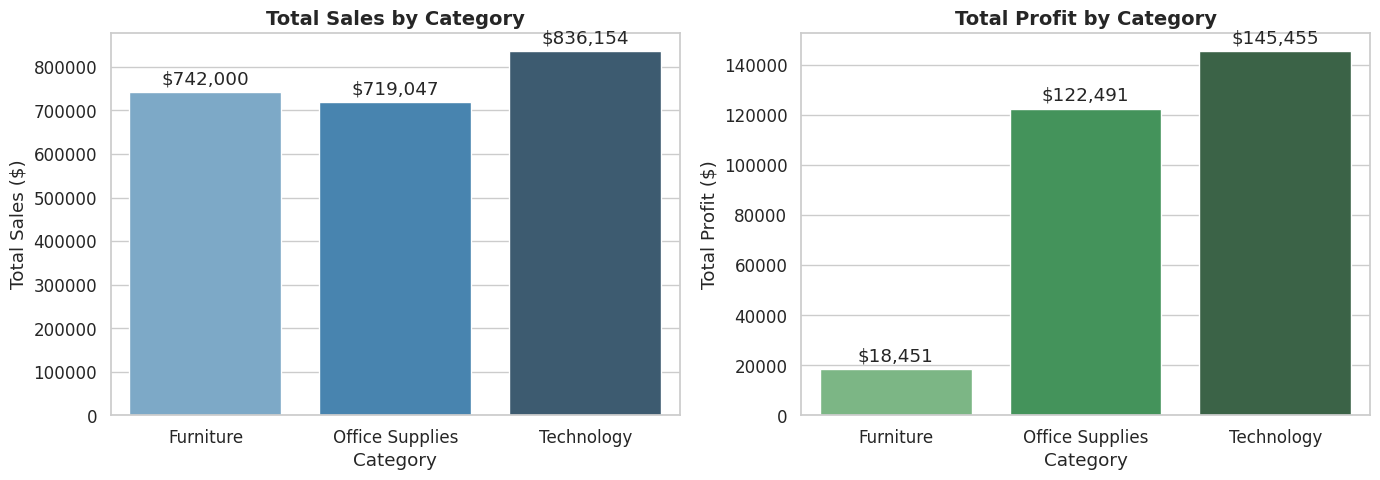

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left chart: Sales by Category ---
#barplot draws each bar per category ; x is the label, y is the height :

sns.barplot(
    data=cat_stats,
    x='Category',
    y='Total_sales',
     palette='Blues_d',
    hue = 'Category',
    ax=axes[0])
axes[0].set_title("Total Sales by Category", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales ($)")

#Add value labels on top of each bar so the extract number is visible :
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='${:,.0f}', padding=3)

#-- Right chart: Profit by Category : --
sns.barplot(
    data=cat_stats,
    x='Category',
    y='Total_profit',
     palette='Greens_d',
     ax=axes[1])
axes[1].set_title("Total Profit by Category", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Profit ($)")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='${:,.0f}', padding=3)

plt.tight_layout()
plt.savefig('bq1_category_sales_profit.png', dpi=150, bbox_inches='tight')
plt.show()

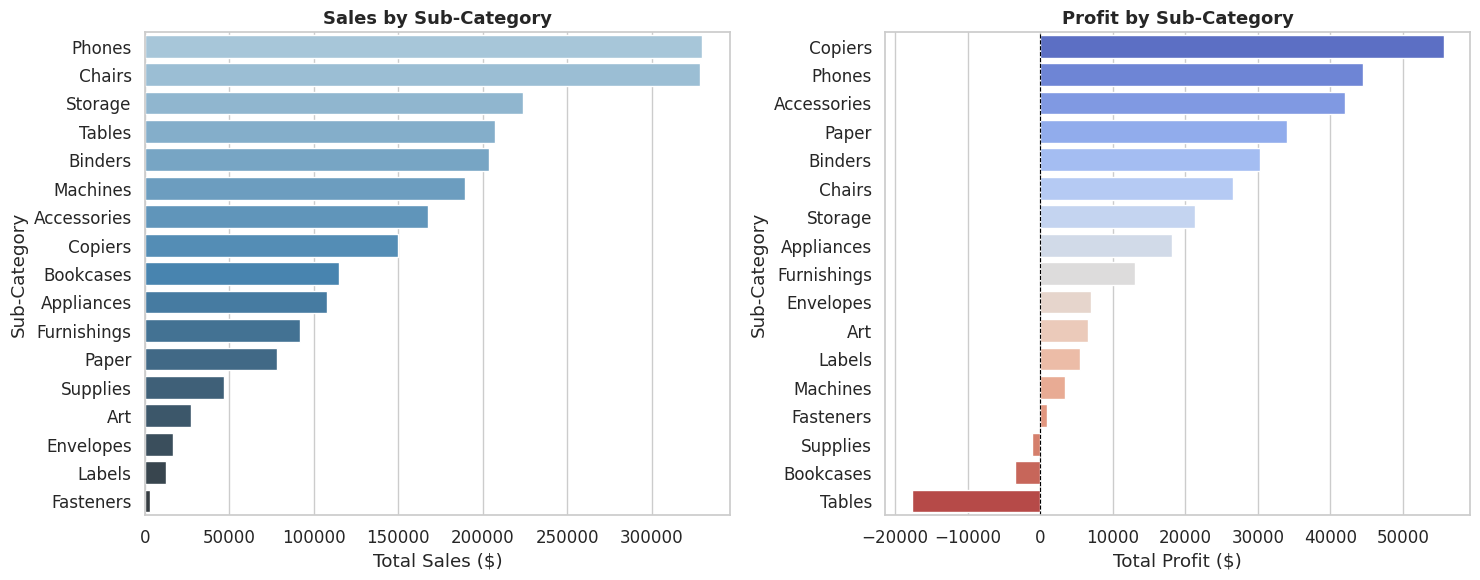

In [ ]:
# -- Sub-Category breakdown ---
#Same logic as above but grouped by Sub-Category for finer detail :
subcat = df.groupby('Sub-Category').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index().sort_values('Total_Sales', ascending=False)

# orient = 'h' makes horizontal bars - better when category names are long .
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=subcat,
    x='Total_Sales',
    y='Sub-Category',
    hue = 'Sub-Category',
            palette='Blues_d',
     orient='h',
    ax=axes[0])

axes[0].set_title("Sales by Sub-Category", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Total Sales ($)")

subcat_profit = subcat.sort_values('Total_Profit', ascending=False)

# Use a diverging palette (coolwarm) so negative profits appear in red automatically
sns.barplot(
    data=subcat_profit,
    x='Total_Profit',
    y='Sub-Category',
            hue = 'Sub-Category',
    palette='coolwarm',
    orient='h',
    ax=axes[1])

axes[1].set_title("Profit by Sub-Category", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Total Profit ($)")

# Draw a vertical line at 0 so loss-making sub-categories are visually obvious
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('bq1b_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

The highest total sales are for technology, but furniture has sub-categories (Tables) that are running at a loss. The most efficient category is Office Supplies, as it has the highest profit margin per sales volume. Sub-categories such as Copiers and Phones are the biggest revenue categories, whilst Tables and Bookcases are loss making and require a price review.

**Question 2 : How do sales trend over time across years and months?**

**Importance:**

A business unaware of its own seasonality is permanently reactive - understocked at peaks,
Too much stock sits in bins. Spotting regular timing trends helps act ahead
inventory planning, targeted marketing, and better logistics scheduling.


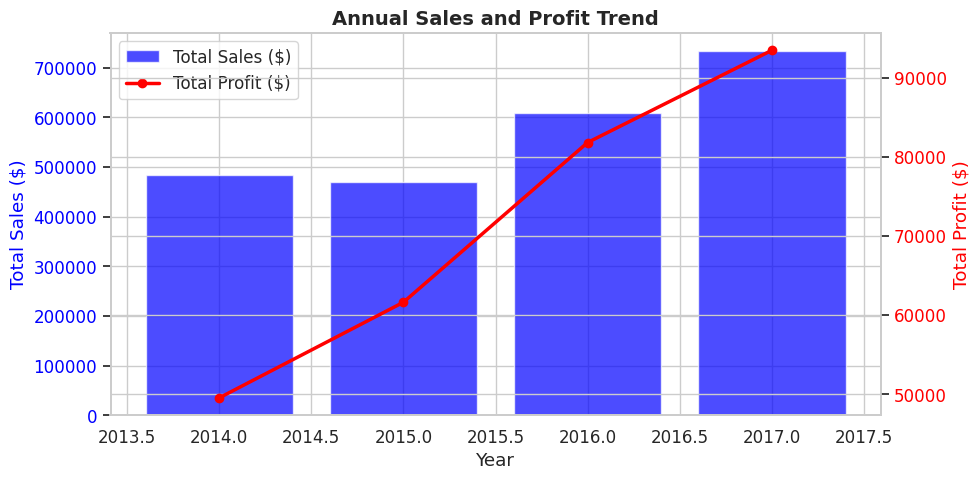

In [ ]:
#Annual Sales Trend ---
yearly = df.groupby('Order Year').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count  = ('Order ID', 'count')
).reset_index()


fig, ax1 = plt.subplots(figsize=(10, 5))

#Plot bars for Sales (left y-axis)
color1 = 'blue'
ax1.bar(yearly['Order Year'], yearly['Total_Sales'],
        color=color1, alpha=0.7, label='Total Sales ($)')
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Sales ($)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)


# .twinx() creates a second y-axis sharing the same x-axis :
#lets us overlay a line (profit) on top of bars (Sales) with different scales --
ax2 = ax1.twinx()
color2 = 'red'
ax2.plot(yearly['Order Year'],
         yearly['Total_Profit'],
         color=color2, marker='o',
         linewidth=2.5,
         label='Total Profit ($)')
ax2.set_ylabel("Total Profit ($)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Merge both legends into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Annual Sales and Profit Trend", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bq2_annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

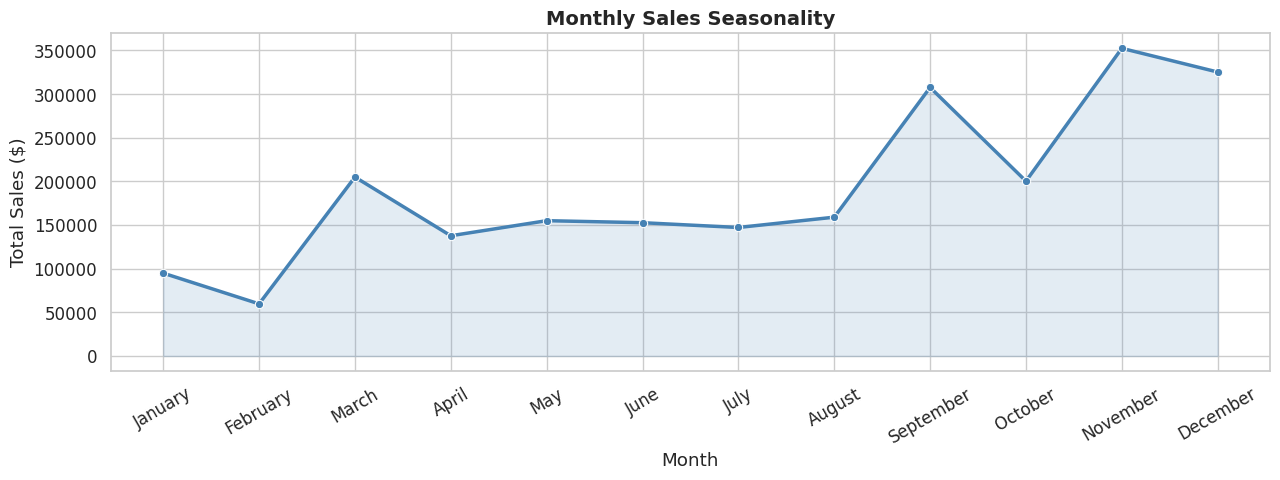

In [ ]:
# -- Monthly Seasonality ---
# Defining the correct calender order so months display jan to dec...
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']


#pd.Categorical with ordered = true enforces this ordering in plots :
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

monthly = df.groupby('Month Name', observed=True)['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Total Sales']

plt.figure(figsize=(13, 5))

#lineplot with marker = 'o' draws a connected line with dots at each point --
# its useful for showing trends/patterns over ordered time periods :
sns.lineplot(data=monthly, x='Month', y='Total Sales',
             marker='o', linewidth=2.5, color='steelblue')

# Fill the area under the line - makes seasonal pattern more visually striking --
plt.fill_between(range(len(monthly)), monthly['Total Sales'], alpha=0.15, color='steelblue')

plt.title("Monthly Sales Seasonality", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(len(monthly)), monthly['Month'], rotation=30)
plt.tight_layout()
plt.savefig('bq2b_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

There is an evident year-on-year increase in sales between 2015 and 2018. The pattern is consistent: sales decrease in February, get steadily better through the year, then pick up in November-December, as people start buying in the holidays. The business needs to schedule stock and staffing to accommodate the increase in demand during Q4.

 **Question 3 : Which states and regions are most profitable?**

**Importance:**

Just because money comes in fast doesn’t mean much is left over. Some places sell a lot but spend so heavily it barely shows on the bottom line
When profits dip below zero, trouble follows. The review shows exactly where the company
is genuinely creating value geographically and where a pricing or discount review is overdue.r product mix review.


/tmp/ipykernel_2477/1486288733.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region,
/tmp/ipykernel_2477/1486288733.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region,


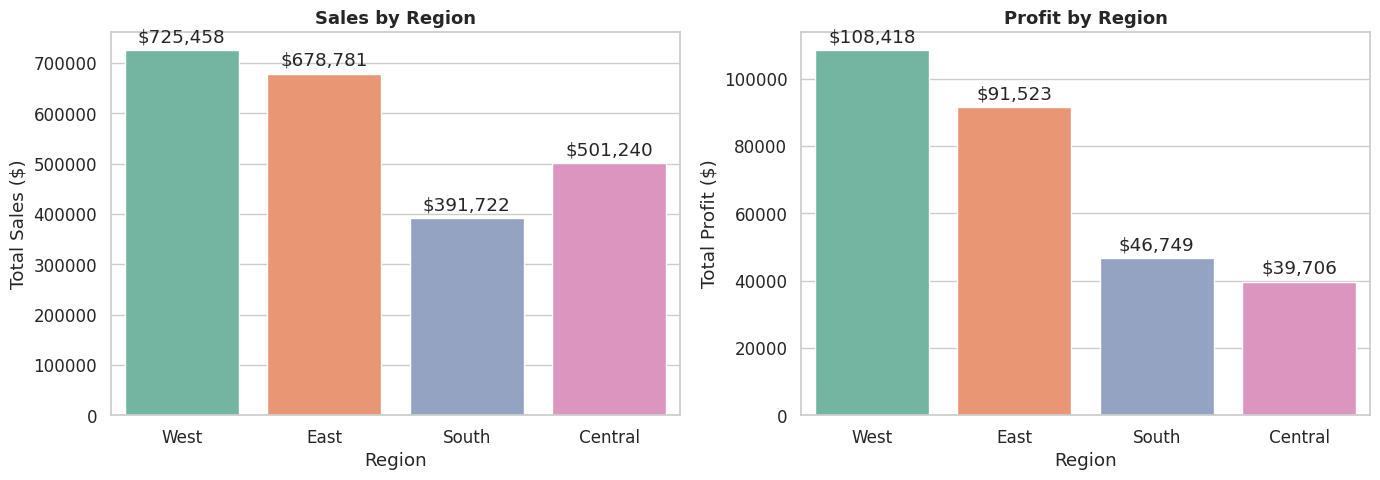

In [ ]:
#Reigon-level Analysis ---
region = df.groupby('Region').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Order_Count   = ('Order ID', 'count')
).reset_index().sort_values('Total_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region,
            x='Region',
            y='Total_Sales',
            palette='Set2',
            ax=axes[0])
axes[0].set_title("Sales by Region", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Total Sales ($)")

for c in axes[0].containers:
    axes[0].bar_label(c, fmt='${:,.0f}', padding=3)

sns.barplot(data=region,
            x='Region',
            y='Total_Profit',
            palette='Set2',
            ax=axes[1])
axes[1].set_title("Profit by Region", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Profit ($)")

for c in axes[1].containers:
    axes[1].bar_label(c, fmt='${:,.0f}', padding=3)

plt.tight_layout()
plt.savefig('bq3_region.png', dpi=150, bbox_inches='tight')
plt.show()

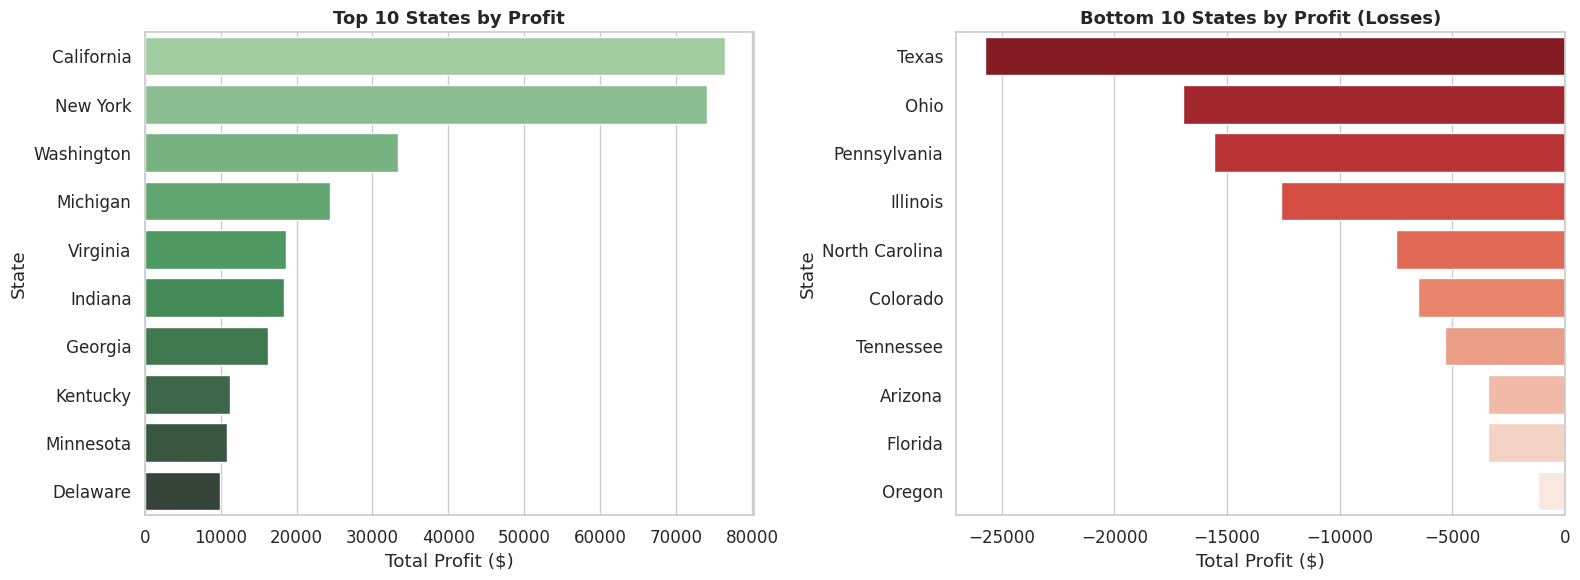

In [ ]:
# --- Top 10 and Bottom 10 States by Profit ---
state_profit = df.groupby('State')['Profit'].sum().reset_index()
state_profit.columns = ['State', 'Total Profit']

top10    = state_profit.nlargest(10, 'Total Profit')   # .nlargest() picks the 10 highest values
bottom10 = state_profit.nsmallest(10, 'Total Profit')  # .nsmallest() picks the 10 lowest values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10,
            x='Total Profit',
            y='State',
            hue = 'State',
            palette='Greens_d',
            orient='h',
            ax=axes[0])
axes[0].set_title("Top 10 States by Profit", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Total Profit ($)")

sns.barplot(data=bottom10,
            x='Total Profit',
            y='State',
            hue = 'State',
            palette='Reds_r',
            orient='h',
            ax=axes[1])
axes[1].set_title("Bottom 10 States by Profit (Losses)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Total Profit ($)")

# Vertical line at 0 highlights which states are actually losing money
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('bq3b_state_profit.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

Most profitable regions are the West and the East. California and New York are the highest scoring states. But states such as Texas make a lot of sales and yet they are actually loss leaders; this is a red flag that suggests that they are over discounting or shipping items at a higher cost in those states.


**Question 4 : Do discounts hurt profitability?**

**Importance:**

Most folks get it wrong when they cut prices at stores. When shoppers pick up about the same amount
Even with different discounts, the company still loses profit. Knowing
the true discount-profit relationship is essential before any pricing policy decision.

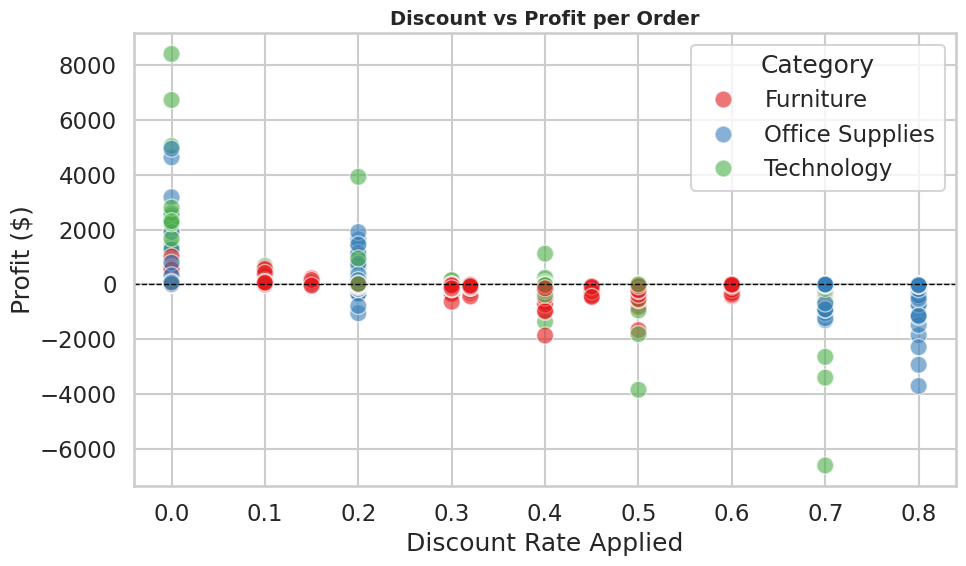

In [ ]:
# --- Discount vs Profit Scatter Plot ---
plt.figure(figsize=(10, 6))

#scatterplot draws one dot per order , coloured by category --
# Alpha = 0.6 makes dots semi-transparent so overlapping points are still visible
sns.set_context('talk')
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.6,
    palette='Set1',
    s = 150)

# Draws a horizontal references line at profit= 0 to show break-even boundary
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title("Discount vs Profit per Order", fontsize=14, fontweight='bold')
plt.xlabel("Discount Rate Applied")
plt.ylabel("Profit ($)")
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('bq4_discount_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

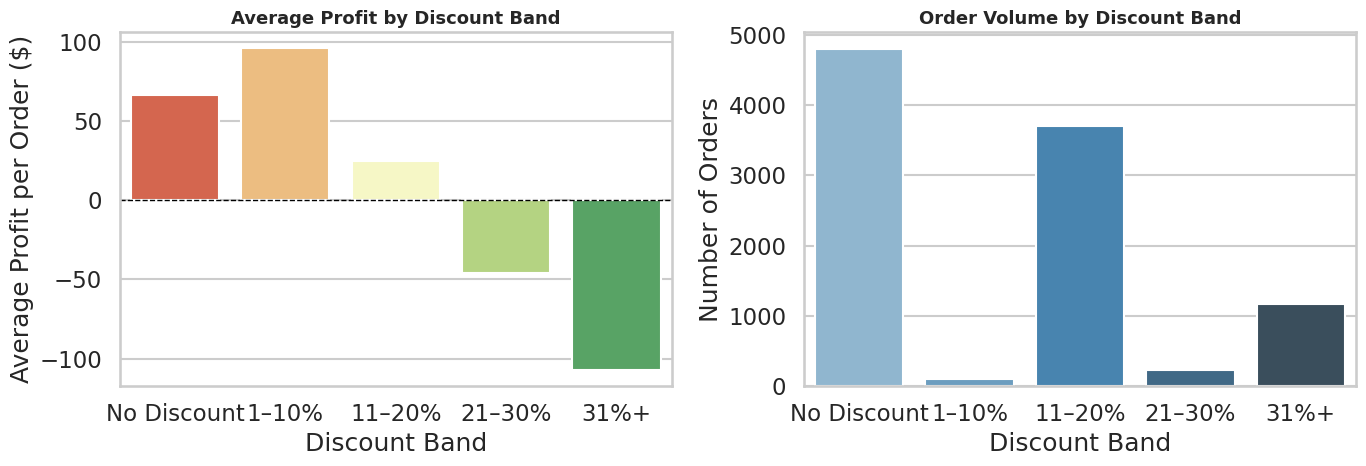

Discount Band  Avg_Profit  Order_Count
  No Discount   66.900292         4798
        1–10%   96.055074           94
       11–20%   24.738824         3709
       21–30%  -45.679636          227
         31%+ -107.209930         1166


In [ ]:
# --- Average profit by disount band ---
# pd.cut() bins the continuous Discount column into 5 named ranges
# This converts continous variable into caategorical one for grouped analysis.
df['Discount Band'] = pd.cut(df['Discount'],
                              bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.9],
                              labels=['No Discount', '1–10%', '11–20%', '21–30%', '31%+'])

disc_profit = df.groupby('Discount Band', observed=True).agg(
    Avg_Profit = ('Profit', 'mean'),
    Order_Count = ('Order ID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=disc_profit,
    x='Discount Band',
    y='Avg_Profit',
    hue='Discount Band',
    palette='RdYlGn',
    ax=axes[0])
axes[0].set_title("Average Profit by Discount Band", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Discount Band")
axes[0].set_ylabel("Average Profit per Order ($)")
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')

sns.barplot(
    data=disc_profit,
    x='Discount Band',
    y='Order_Count',
    hue='Discount Band',
    palette='Blues_d',
    ax=axes[1])
axes[1].set_title("Order Volume by Discount Band", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Discount Band")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig('bq4b_discount_bands.png', dpi=150, bbox_inches='tight')
plt.show()

print(disc_profit.to_string(index=False))

Interpretation:

The relationship is inversely proportional, that is, the higher the discount rates the lower the average profit per order, and eventually the average profit per order will become negative. The most profitable are orders with no discount. Losses are the regular result of discounts of more than 20%. The business is pushing the customers to pay, and it is not a viable strategy.




**Question 5 : What are customer segments buying and how profitable are they?**

**Importance:**

Some buyers need different prices, others expect unique support. Looking at groups shows patterns
where the most profitable relationships are concentrated and where a targeted growth
strategy would deliver the highest return.


    Segment  Total_Sales  Total_Profit  Order_Count  Avg_Order_Val  Profit_Margin_%
   Consumer 1161401.3450   134119.2092         5191     223.733644             11.5
  Corporate  706146.3668    91979.1340         3020     233.823300             13.0
Home Office  429653.1485    60298.6785         1783     240.972041             14.0


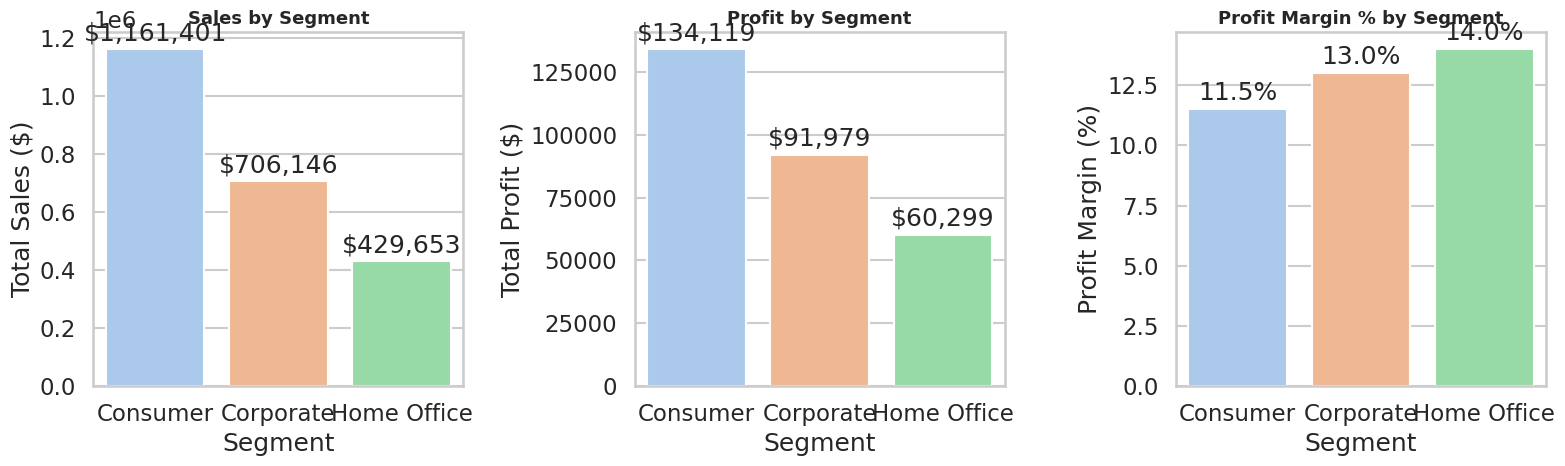

In [ ]:
# -- Segment-level Analysis --
segment = df.groupby('Segment').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Order_Count   = ('Order ID', 'count'),
    Avg_Order_Val = ('Sales', 'mean')
).reset_index()

segment['Profit_Margin_%'] = ((segment['Total_Profit'] / segment['Total_Sales']) * 100).round(1)
segment = segment.sort_values('Total_Profit', ascending=False)

print(segment.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=segment,
    x='Segment',
    y='Total_Sales',
    hue = 'Segment',
    palette='pastel',
    ax=axes[0])
axes[0].set_title("Sales by Segment",  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Total Sales ($)")

for c in axes[0].containers:
   axes[0].bar_label(c, fmt='${:,.0f}', padding=3)

sns.barplot(
    data=segment,
    x='Segment' ,
    y='Total_Profit',
    hue = 'Segment',
    palette='pastel',
    ax=axes[1])
axes[1].set_title("Profit by Segment", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Total Profit ($)")

for c in axes[1].containers:
  axes[1].bar_label(c, fmt='${:,.0f}', padding=3)

sns.barplot(
    data=segment,
    x= 'Segment' ,
    y='Profit_Margin_%',
    hue = 'Segment',
    palette='pastel',
    ax=axes[2])
axes[2].set_title("Profit Margin % by Segment", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Profit Margin (%)")

for c in axes[2].containers:
   axes[2].bar_label(c, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig('bq5_segments.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

Consumer is the biggest segment in terms of sales and profits. Home Office, on the other hand, has the greatest profit margin of all the segments (%), and is the most efficient segment, as every dollar spent on sales turns into profit the best in Home Office. The Corporate segment has high volume but slightly lower margins, so there is a need to investigate whether the bulk discounting is impacting per unit profitability.

**Question 6 : How does delivery speed affect customer behaviour?**

**Importance:**

For shipping, price tags come hand in hand with how happy customers feel. Figuring out transport types
customers choose - and whether faster options are being utilised - informs logistics
partnerships and premium service decisions.


     Ship Mode  Avg_Delivery_Days  Total_Orders  Total_Sales
      Same Day                0.0           543  128363.1250
   First Class                2.2          1538  351428.4229
  Second Class                3.2          1945  459193.5694
Standard Class                5.0          5968 1358215.7430


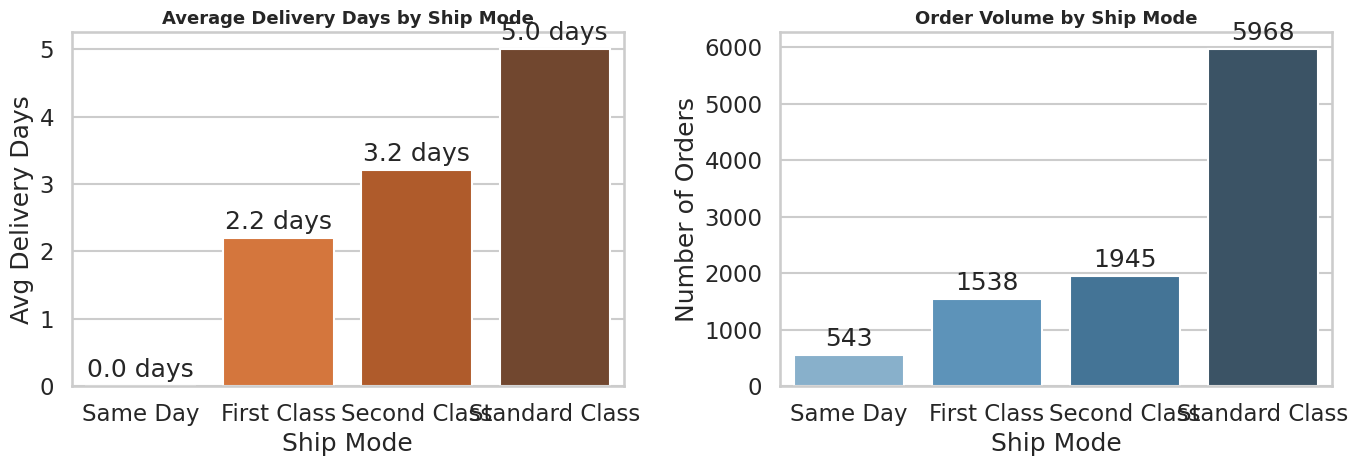

In [ ]:
# ---Delivery Analysis by Ship mode ---
ship = df.groupby('Ship Mode').agg(
    Avg_Delivery_Days = ('Delivery Days', 'mean'),
    Total_Orders      = ('Order ID', 'count'),
    Total_Sales       = ('Sales', 'sum')
).reset_index()

ship['Avg_Delivery_Days'] = ship['Avg_Delivery_Days'].round(1)
ship = ship.sort_values('Avg_Delivery_Days')

print(ship.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=ship, x='Ship Mode',
    y='Avg_Delivery_Days',
    hue = 'Ship Mode',
    palette='Oranges_d',
    ax=axes[0])
axes[0].set_title("Average Delivery Days by Ship Mode", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Avg Delivery Days")

for c in axes[0].containers:
  axes[0].bar_label(c, fmt='%.1f days', padding=3)

sns.barplot(data=ship,
            x='Ship Mode',
            y='Total_Orders',
            hue = 'Ship Mode',
            palette='Blues_d',
            ax=axes[1])
axes[1].set_title("Order Volume by Ship Mode", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Number of Orders")

for c in axes[1].containers:
  axes[1].bar_label(c, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig('bq6_shipping.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

Standard Class is the longest shipping method by far, but it's also by far the most popular shipping method. The use rate for Same Day delivery is low, possibly due to high cost or low awareness. Consider providing quicker shipping discounts for higher dollar customers to increase customer satisfaction and subsequent sales.


#### Question 7: Which individual products are the most and least profitable — and are any products consistently losing money?

**importance:**

One product dragging down profits might hide behind group results. When looked at together, weak items blend into the crowd
A sudden spike in one item’s sales might overshadow everything else nearby. Spotting such shifts early changes how teams respond. Movement in a single product sometimes reshapes the whole section’s performance. Watch closely when one option pulls more attention than usual. Shifts like that often redefine what success looks like across related items
products allows the client to reprice, bundle, or delist them.

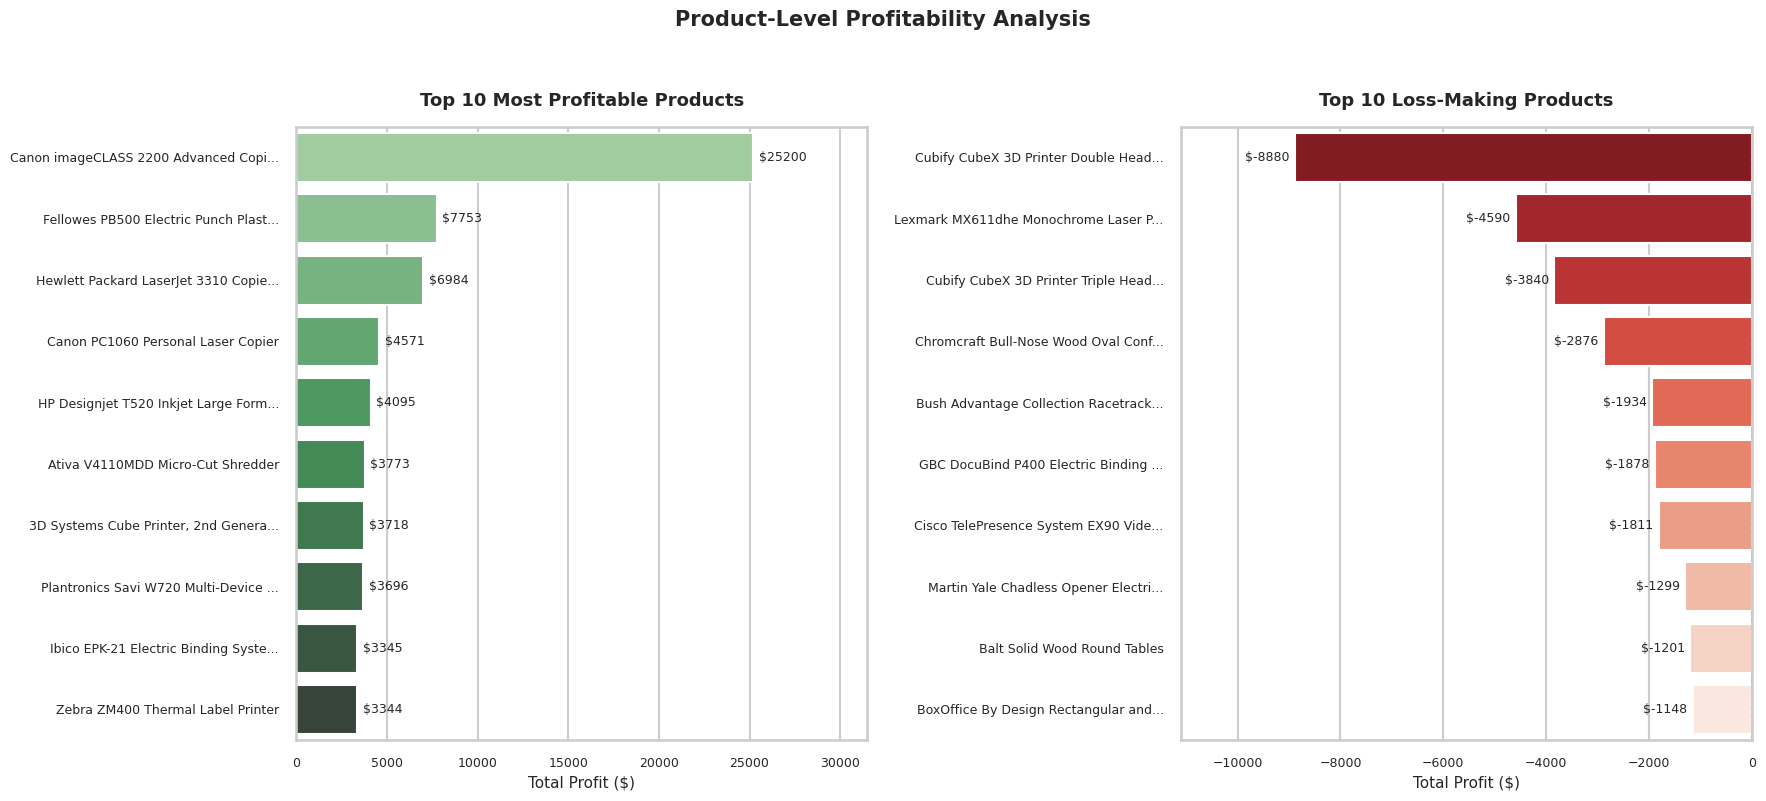

Top 10 loss-making products:
                               Product  Total Profit
Cubify CubeX 3D Printer Double Head...    -8879.9704
Lexmark MX611dhe Monochrome Laser P...    -4589.9730
Cubify CubeX 3D Printer Triple Head...    -3839.9904
Chromcraft Bull-Nose Wood Oval Conf...    -2876.1156
Bush Advantage Collection Racetrack...    -1934.3976
GBC DocuBind P400 Electric Binding ...    -1878.1662
Cisco TelePresence System EX90 Vide...    -1811.0784
Martin Yale Chadless Opener Electri...    -1299.1836
          Balt Solid Wood Round Tables    -1201.0581
BoxOffice By Design Rectangular and...    -1148.4375


In [ ]:
# --- Top 10 and Bottom 10 Products by Profit ---

product_profit = df.groupby('Product Name')['Profit'].sum().reset_index()
product_profit.columns = ['Product', 'Total Profit']

top10_products    = product_profit.nlargest(10, 'Total Profit')
bottom10_products = product_profit.nsmallest(10, 'Total Profit')

#  Shortening long product names --
top10_products    = top10_products.copy()
bottom10_products = bottom10_products.copy()

top10_products['Product']    = top10_products['Product'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x)
bottom10_products['Product'] = bottom10_products['Product'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x)

# --- Using a TALL figure  ---
# figsize=(width, height) — increasing height gives each label its own vertical space
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Top 10 most profitable ---
sns.barplot(
    data=top10_products,
    x='Total Profit',
    y='Product',
   hue = 'Product',
    palette='Greens_d',
    orient='h',
    ax=axes[0])
axes[0].set_title("Top 10 Most Profitable Products", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Total Profit ($)", fontsize=11)
axes[0].set_ylabel("")

# Adding value labels at the end of each bar for exact numbers
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%.0f', padding=4, fontsize=9)

# Increasing font size of y-axis labels so product names are better--
axes[0].tick_params(axis='y', labelsize=9)
axes[0].tick_params(axis='x', labelsize=9)

# Adding extra right margin so value labels  --
axes[0].set_xlim(0, top10_products['Total Profit'].max() * 1.25)

# --- Right: Top 10 loss-making ---
sns.barplot(
    data=bottom10_products,
    x='Total Profit',
    y='Product',
    hue = 'Product',
     palette='Reds_r',
    orient='h',
    ax=axes[1])
axes[1].set_title("Top 10 Loss-Making Products", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Total Profit ($)", fontsize=11)
axes[1].set_ylabel("")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='$%.0f', padding=4, fontsize=9)

axes[1].tick_params(axis='y', labelsize=9)
axes[1].tick_params(axis='x', labelsize=9)

# Extend left margin for the loss chart ---
axes[1].set_xlim(bottom10_products['Total Profit'].min() * 1.25, 0)

# Vertical line at 0 makes loss-making boundary crystal clear --
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')

# Adding a light grey background to each subplot for visual contrast --
for ax in axes:
    ax.set_facecolor('white')

plt.suptitle("Product-Level Profitability Analysis",
             fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq7_product_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 loss-making products:")
print(bottom10_products.to_string(index=False))

**Interpretation:**

Out front, pricey tech gear pulls ahead - especially Canon, Fellowes, and HP laser printers and copiers. With solid markups baked in, these items command top dollar across business buyers. Their steady demand powers much of what lifts the entire Tech segment. From there, results follow.

Out here, losing money paints a clearer picture. Take Furniture. That’s where things get rough - conference tables, chairs, even binding systems dragging down results because deep cuts in price hit each one too hard

**Correlation Heatmap:**

**Question 8 : How do the key numerical variables relate to each other?**

**Importance:**

One chart tackles just a single query. Meanwhile, a correlation matrix reveals connections across every main factor
variables interact simultaneously - revealing which levers genuinely move profit rather
than just creating the appearance of movement.

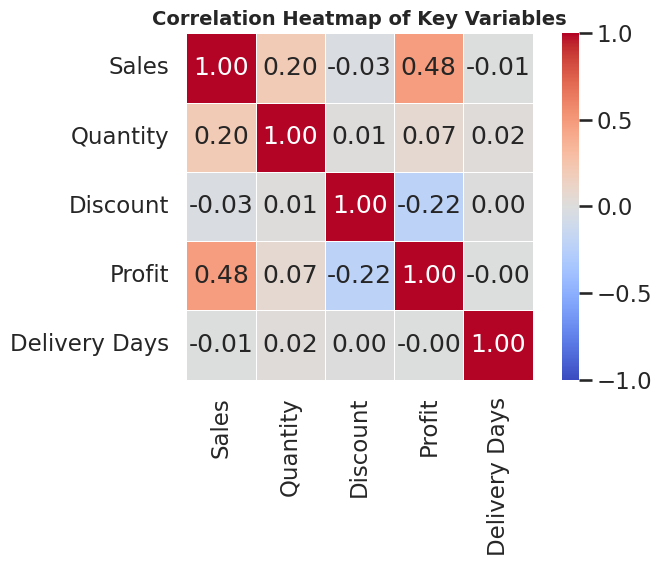

In [ ]:
# -- Correlation Matrix ---
# A correlation matrix shows how strongly pairs of numeric variables move together
#values close to [+1, -1, 0] = relationship[positive, negative, no meaningful]

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Delivery Days']
corr_matrix = df[numeric_cols].corr()  # .corr() computes pairwise Pearson correlation coefficients

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
     cmap='coolwarm',
     vmin=-1, vmax=1,
      square=True,
    linewidths=0.5)

plt.title("Correlation Heatmap of Key Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bq7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

Surprisingly, the strongest trend here shows discounting ties to lower profit - about  -0.22 on the scale. Notably, more sales sometimes link to better gains. Still, that connection stays faint. Especially when cuts in price come into play. Oddly enough, moving units fast won’t lift earnings much under heavy discounts. Roughly speaking, trading volume helps only so far.

**Final Discussion and Conclusion**

**Key Findings Business Implications**

**Finding Recommendation**

1.Technology leads sales; offces Suüülies has best profit margin ; tables and bookcases are loss-making.

*Reprice or discontinuing loss making furniture sub.categories.


2.Sales peak every year(Nov- Dec).

*Beginning inventory planning by september.

3.West and East lead profit; Texas and ohio are loss-making despite high sales.

*Very important to review discounting policy in cdntral and South regions.

4.Discounts above 20% consistentaly produce losses with no volume uplift.

*cap maximum discount at 15% across all categories.

5.Consumer is largest segment ; Home office has highest profit margin.

*Target home office with premium product campaigns.

6.Standard Class dominates; Same Day is underused.

*Trial free upgrades for high-value orders above $500

7.A small number of individual products account for most losses.

*Review and delist bottom 20 loss-making SKUs.
---

**Strengths**

Seven questions dive into timing, what’s being sold, where it happens, how much it costs, who it's for, along with shifts in market slices, topped off by patterns in customer behavior.

Running things day to day plus how each product sells adds up to a clear picture of how the company is doing.
Because both sales numbers and earnings got checked at once, it stopped people from focusing on just one.


Most people chase more income without watching profit loss. One wrong step here burns cash fast. Focus slips when only sales matter. Profit fades even if numbers rise. Bigger does not mean better always. Watch what stays after costs take their share. Numbers can lie loud that way.


On top of cleaning up repeated entries, dates got turned into proper formats right away. Handling data started with solid steps that made later stages smoother. Fixing time labels came before anything else slipped through. Removing double records happened early so nothing skewed results down the line
Creating features such as Delivery Days and Quarter happened early, well ahead of diving into the data. Instead of waiting, these variables took shape at the start. Built right in, they shaped how patterns later emerged.

Before any charts or summaries appeared, those elements already existed. Their presence guided what came next without delay.
Picture by picture, clarity shaped every design choice. Not looks. Truth mattered most. A bar here because it shows gaps without tricks. Lines appear only when trends need connecting. Shapes stay simple so numbers speak louder.

Every pick served understanding first. Deception had no role. Even colors were picked to reveal, never distract
Start with dots when connections matter. Lines show change over time. A grid of colors reveals hidden links between things.

---

**Limitations**

One purchase didn’t shape the next. Each time someone bought, it stood alone. Repeat buyers meant nothing to the system. Past orders had zero effect on future ones. Someone could shop every week, still seen as new each visit
Twelve purchases hold much greater worth compared to someone who buys once - such insight simply doesn’t compute without looking closely
distinguish between them.


Just because two things happen together does not mean one causes the other. A link between discounts and profits comes from observation only.
One way to check if discounts really lead to less might involve flipping a coin to pick groups. Chance alone should decide who gets the special price. To know for sure, each side needs equal odds of being chosen. Only after running it can we see what actually happens. The result comes from letting luck guide who sees the deal
earnings instead of just moving alongside products with thin margins.

Even without return figures, a reversed transaction counts for nothing. When particular groups see lots of comebacks,
Because of how returns are counted, these earnings numbers might look bigger than they really are - especially in
Furniture.

One shop. One nation. Every result ties back to this American company alone
From 2015 to 2018 lies the limit of this data - wider claims need more proof. Yet even then, it might not hold up elsewhere.

---

**Final Recommendations**

Start by cutting red tape fast - this opens doors quickly. A surprise move, but shifting funds to frontline services hits harder than expected. Lastly, teaming up with local groups builds strength nobody saw coming

- A limit hits - no more than 15% off allowed. Discounts that go higher? Gone without warning
This line marks the quickest path toward better margins.

- Conduct an immediate SKU-level review of the bottom 20 products by profit and
Remove listings of those operating at a loss for more than twenty-four months when they lack a clear business purpose.

- Build a basic Q4 demand forecast - the seasonal pattern is consistent enough
Throughout each of the four years, a basic setup could clearly boost stock handling
How you stand when markets hit their busiest stretch.

It's obvious what the numbers show. Now comes actually doing it.

---

### References

Kaggle (2022) *Superstore Sales Dataset*. Available at:
https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
[Accessed: June 2025].

McKinney, W. (2022) *Python for Data Analysis*. 3rd edn. Sebastopol: O'Reilly Media.

VanderPlas, J. (2016) *Python Data Science Handbook*. Sebastopol: O'Reilly Media.
Available at: https://jakevdp.github.io/PythonDataScienceHandbook/ [Accessed: June 2025].

Wickham, H. (2016) *ggplot2: Elegant Graphics for Data Analysis*. New York: Springer.

Provost, F. and Fawcett, T. (2013) *Data Science for Business*. Sebastopol: O'Reilly Media.